In [52]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [53]:
df_train = pd.read_csv(r'C:\Users\ayush\Credit_Risk_Analysis\Credit_Score_Preprocessing_and_Prediction\train.csv', index_col='ID')
df_train

C:\Users\ayush\AppData\Local\Temp\ipykernel_6292\64663548.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv(r'C:\Users\ayush\Credit_Risk_Analysis\Credit_Score_Preprocessing_and_Prediction\train.csv', index_col='ID')


,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor


In [55]:
print('Number of rows:{}'.format(df_train.shape[0]))
print('Number of columns:{}'.format(df_train.shape[1]))

Number of rows:100000
Number of columns:27


In [56]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0x1602 to 0x25fed
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   Month                     100000 non-null  object 
 2   Name                      90015 non-null   object 
 3   Age                       100000 non-null  object 
 4   SSN                       100000 non-null  object 
 5   Occupation                100000 non-null  object 
 6   Annual_Income             100000 non-null  object 
 7   Monthly_Inhand_Salary     84998 non-null   float64
 8   Num_Bank_Accounts         100000 non-null  int64  
 9   Num_Credit_Card           100000 non-null  int64  
 10  Interest_Rate             100000 non-null  int64  
 11  Num_of_Loan               100000 non-null  object 
 12  Type_of_Loan              88592 non-null   object 
 13  Delay_from_due_date       100000 non-null  

In [58]:
df_train.describe(include='all')

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,90015,100000,100000,100000,100000,84998.000000,100000.000000,100000.00000,...,100000,100000,100000.000000,90970,100000,100000.000000,95521,100000,98800,100000
unique,12500,8,10139,1788,12501,16,18940,NaN,NaN,NaN,...,4,13178,NaN,404,3,NaN,91049,7,98792,3
top,CUS_0xd40,January,Langep,38,#F%$D@*&8,_______,36585.12,NaN,NaN,NaN,...,Standard,1360.45,NaN,15 Years and 11 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,8,12500,44,2833,5572,7062,16,NaN,NaN,NaN,...,36479,24,NaN,446,52326,NaN,4305,25513,9,53174
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4194.170850,17.091280,22.47443,...,NaN,NaN,32.285173,NaN,NaN,1403.118217,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.686167,117.404834,129.05741,...,NaN,NaN,5.116875,NaN,NaN,8306.041270,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,0.00000,...,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1625.568229,3.000000,4.00000,...,NaN,NaN,28.052567,NaN,NaN,30.306660,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3093.745000,6.000000,5.00000,...,NaN,NaN,32.305784,NaN,NaN,69.249473,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5957.448333,7.000000,7.00000,...,NaN,NaN,36.496663,NaN,NaN,161.224249,NaN,NaN,NaN,NaN


In [59]:
df_datatypes = pd.DataFrame(df_train.dtypes).reset_index().rename(columns={0:'Datatype', 'index' : 'Column Name'})

categorical_df = df_datatypes[df_datatypes['Datatype'] == 'object']
numerical_df = df_datatypes[df_datatypes['Datatype']!='object']

Numerical_Columns= list((numerical_df['Column Name']))
Categorical_Columns= list((categorical_df['Column Name']))

print(Numerical_Columns)
print(Categorical_Columns)

['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']
['Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


In [60]:
df_train[list(numerical_df['Column Name'])].describe()


,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [61]:
df_train[list(categorical_df['Column Name'])].describe()

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,90015,100000,100000,100000,100000,100000,88592,92998,100000,100000,100000,90970,100000,95521,100000,98800,100000
unique,12500,8,10139,1788,12501,16,18940,434,6260,749,4384,4,13178,404,3,91049,7,98792,3
top,CUS_0xd40,January,Langep,38,#F%$D@*&8,_______,36585.12,3,Not Specified,19,_,Standard,1360.45,15 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,8,12500,44,2833,5572,7062,16,14386,1408,5327,2091,36479,24,446,52326,4305,25513,9,53174


In [62]:
#keeping df_train as the original we make a copy of it.
train_data=df_train

In [63]:
# Categorical Cols
categorical_cols = [c for c in train_data.columns if train_data[c].dtype == 'object']

In [64]:
#There are something like started and/or ended with "_" 
#or some other values lile !@# etc

for col in categorical_cols:
    train_data[col] = train_data[col].str.strip('_')

    try:
        train_data[col] = train_data[col].astype('float64')
    except:
        train_data[col] = train_data[col]
        

for col in categorical_cols:
    train_data[col] = train_data[col].replace({'':np.nan})

    try:
        train_data[col] = train_data[col].astype('float64')
    except:
        train_data[col] = train_data[col]

for col in categorical_cols:
    train_data[col] = train_data[col].replace({'!@9#%8':np.nan, '#F%$D@*&8':np.nan})

In [65]:
train_data[categorical_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0x1602 to 0x25fed
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              100000 non-null  object 
 1   Month                    100000 non-null  object 
 2   Name                     90015 non-null   object 
 3   Age                      100000 non-null  float64
 4   SSN                      94428 non-null   object 
 5   Occupation               92938 non-null   object 
 6   Annual_Income            100000 non-null  float64
 7   Num_of_Loan              100000 non-null  float64
 8   Type_of_Loan             88592 non-null   object 
 9   Num_of_Delayed_Payment   92998 non-null   float64
 10  Changed_Credit_Limit     97909 non-null   float64
 11  Credit_Mix               79805 non-null   object 
 12  Outstanding_Debt         100000 non-null  float64
 13  Credit_History_Age       90970 non-null   object 
 14  Pay

In [66]:
#We want "Credit history age" in YY years only
credit_age = []
for i in train_data['Credit_History_Age']:
    credit_age.append(str(i).split(' ')[0])
    
train_data['Credit_History_Age'] = credit_age

train_data['Credit_History_Age'] = train_data['Credit_History_Age'].replace({'nan':np.nan})
train_data['Credit_History_Age'] = train_data['Credit_History_Age'].astype('float64')

In [67]:
#Handling the outliers in the data like improper age  

numerical_cols = [col for col in train_data.columns if (train_data[col].dtype == 'int64') | (train_data[col].dtype == 'float64')]

for x in list(numerical_cols):
    q75,q25 = np.percentile(train_data.loc[:,x],[75,25])
    intr_qr = q75-q25
 
    max = q75+(1.5*intr_qr)
    min = q25-(1.5*intr_qr)
 
    train_data.loc[train_data[x] < min,x] = np.nan
    train_data.loc[train_data[x] > max,x] = np.nan

In [68]:
#We can drop the "Type of loan"column
train_data.drop(columns=['Type_of_Loan'], axis=1, inplace=True)

In [69]:
#Checking the missing data
train_data.isnull().sum()

Customer_ID                     0
Month                           0
Name                         9985
Age                          2781
SSN                          5572
Occupation                   7062
Annual_Income                2783
Monthly_Inhand_Salary       15002
Num_Bank_Accounts            1315
Num_Credit_Card              2271
Interest_Rate                2034
Num_of_Loan                  4348
Delay_from_due_date          4002
Num_of_Delayed_Payment       7002
Changed_Credit_Limit         2091
Num_Credit_Inquiries         1965
Credit_Mix                  20195
Outstanding_Debt             5272
Credit_Utilization_Ratio        4
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month          6795
Amount_invested_monthly      4479
Payment_Behaviour            7600
Monthly_Balance              2868
Credit_Score                    0
dtype: int64

<AxesSubplot:>

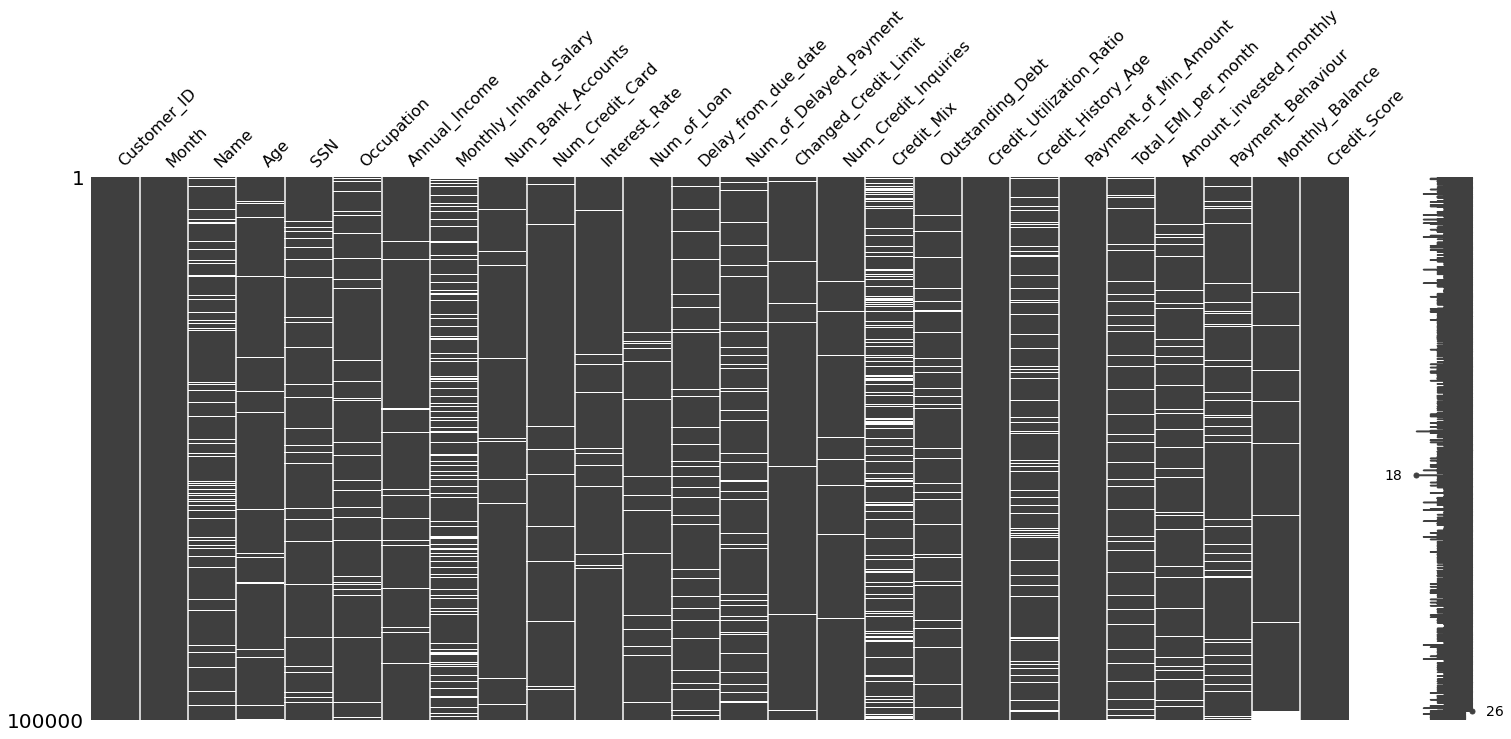

In [70]:
msno.matrix(train_data)

In [71]:
missing = train_data.isnull().sum()
missing = missing[missing>0]
missing

Name                         9985
Age                          2781
SSN                          5572
Occupation                   7062
Annual_Income                2783
Monthly_Inhand_Salary       15002
Num_Bank_Accounts            1315
Num_Credit_Card              2271
Interest_Rate                2034
Num_of_Loan                  4348
Delay_from_due_date          4002
Num_of_Delayed_Payment       7002
Changed_Credit_Limit         2091
Num_Credit_Inquiries         1965
Credit_Mix                  20195
Outstanding_Debt             5272
Credit_Utilization_Ratio        4
Credit_History_Age           9030
Total_EMI_per_month          6795
Amount_invested_monthly      4479
Payment_Behaviour            7600
Monthly_Balance              2868
dtype: int64

In [72]:
missing_cols = [col for col in missing.index]
missing_cols.append('Customer_ID')
missing_cols

['Name',
 'Age',
 'SSN',
 'Occupation',
 'Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Credit_Mix',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Credit_History_Age',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Payment_Behaviour',
 'Monthly_Balance',
 'Customer_ID']

In [73]:
#Going with the numerical missing columns first

missing_cols_set = set(missing_cols)
missing_cols_set

{'Age',
 'Amount_invested_monthly',
 'Annual_Income',
 'Changed_Credit_Limit',
 'Credit_History_Age',
 'Credit_Mix',
 'Credit_Utilization_Ratio',
 'Customer_ID',
 'Delay_from_due_date',
 'Interest_Rate',
 'Monthly_Balance',
 'Monthly_Inhand_Salary',
 'Name',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Num_Credit_Inquiries',
 'Num_of_Delayed_Payment',
 'Num_of_Loan',
 'Occupation',
 'Outstanding_Debt',
 'Payment_Behaviour',
 'SSN',
 'Total_EMI_per_month'}

In [74]:
# numerical cols with missing values
numerical_cols_set = {col for col in train_data.columns if (train_data[col].dtype=='int64') | (train_data[col].dtype=='float64')}
numerical_cols_missing = [col for col in numerical_cols_set.intersection(missing_cols_set)]
numerical_cols_missing.append('Customer_ID')
numerical_cols_missing

['Num_Credit_Inquiries',
 'Num_Bank_Accounts',
 'Num_of_Delayed_Payment',
 'Interest_Rate',
 'Age',
 'Delay_from_due_date',
 'Monthly_Balance',
 'Num_Credit_Card',
 'Amount_invested_monthly',
 'Monthly_Inhand_Salary',
 'Credit_Utilization_Ratio',
 'Num_of_Loan',
 'Annual_Income',
 'Total_EMI_per_month',
 'Changed_Credit_Limit',
 'Credit_History_Age',
 'Outstanding_Debt',
 'Customer_ID']

In [75]:
train_data[numerical_cols_missing]

,Num_Credit_Inquiries,Num_Bank_Accounts,Num_of_Delayed_Payment,Interest_Rate,Age,Delay_from_due_date,Monthly_Balance,Num_Credit_Card,Amount_invested_monthly,Monthly_Inhand_Salary,Credit_Utilization_Ratio,Num_of_Loan,Annual_Income,Total_EMI_per_month,Changed_Credit_Limit,Credit_History_Age,Outstanding_Debt,Customer_ID
ID,,,,,,,,,,,,,,,,,,
0x1602,4.0,3.0,7.0,3.0,23.0,3.0,312.494089,4.0,80.415295,1824.843333,26.822620,4.0,19114.12,49.574949,11.27,22.0,809.98,CUS_0xd40
0x1603,4.0,3.0,NaN,3.0,23.0,-1.0,284.629162,4.0,118.280222,NaN,31.944960,4.0,19114.12,49.574949,11.27,NaN,809.98,CUS_0xd40
0x1604,4.0,3.0,7.0,3.0,NaN,3.0,331.209863,4.0,81.699521,NaN,28.609352,4.0,19114.12,49.574949,NaN,22.0,809.98,CUS_0xd40
0x1605,4.0,3.0,4.0,3.0,23.0,5.0,223.451310,4.0,199.458074,NaN,31.377862,4.0,19114.12,49.574949,6.27,22.0,809.98,CUS_0xd40
0x1606,4.0,3.0,NaN,3.0,23.0,6.0,341.489231,4.0,41.420153,1824.843333,24.797347,4.0,19114.12,49.574949,11.27,22.0,809.98,CUS_0xd40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fe9,3.0,4.0,7.0,7.0,25.0,23.0,NaN,6.0,60.971333,3359.415833,34.663572,2.0,39628.99,35.104023,11.50,31.0,502.38,CUS_0x942c
0x25fea,3.0,4.0,7.0,7.0,25.0,18.0,NaN,6.0,54.185950,3359.415833,40.565631,2.0,39628.99,35.104023,11.50,31.0,502.38,CUS_0x942c
0x25feb,3.0,4.0,6.0,NaN,25.0,27.0,NaN,6.0,24.028477,3359.415833,41.255522,2.0,39628.99,35.104023,11.50,31.0,502.38,CUS_0x942c


In [76]:
missing = train_data.isnull().sum()
missing = missing[missing>0]
missing

Name                         9985
Age                          2781
SSN                          5572
Occupation                   7062
Annual_Income                2783
Monthly_Inhand_Salary       15002
Num_Bank_Accounts            1315
Num_Credit_Card              2271
Interest_Rate                2034
Num_of_Loan                  4348
Delay_from_due_date          4002
Num_of_Delayed_Payment       7002
Changed_Credit_Limit         2091
Num_Credit_Inquiries         1965
Credit_Mix                  20195
Outstanding_Debt             5272
Credit_Utilization_Ratio        4
Credit_History_Age           9030
Total_EMI_per_month          6795
Amount_invested_monthly      4479
Payment_Behaviour            7600
Monthly_Balance              2868
dtype: int64

In [77]:
#We observe that some of the column values are dependent
#on the "Customer ID"

#So we assign the values in missing coulmns by using average
#based on their "Customer Id" and bfill the rest of the columns.

numerical_cols_missing.pop()

'Customer_ID'

In [78]:
train_data.Customer_ID.value_counts()
train_data.Customer_ID.value_counts().value_counts()

#Thus observe that every Custome_ID has 8 values and there are a total of 12500 values of Customer_ID

8    12500
Name: Customer_ID, dtype: int64

In [79]:
based_customer_ID = [col for col in numerical_cols if train_data[col].head(8).nunique() == 1]
non_based_customer_ID = [col for col in numerical_cols if train_data[col].head(8).nunique() != 1]

In [80]:
based_customer_ID, non_based_customer_ID

(['Age',
  'Annual_Income',
  'Monthly_Inhand_Salary',
  'Num_Bank_Accounts',
  'Num_Credit_Card',
  'Interest_Rate',
  'Num_of_Loan',
  'Num_Credit_Inquiries',
  'Outstanding_Debt',
  'Credit_History_Age',
  'Total_EMI_per_month'],
 ['Delay_from_due_date',
  'Num_of_Delayed_Payment',
  'Changed_Credit_Limit',
  'Credit_Utilization_Ratio',
  'Amount_invested_monthly',
  'Monthly_Balance'])

In [81]:
train_data[based_customer_ID] = train_data.groupby(by=['Customer_ID'])[based_customer_ID].transform('median')
train_data[non_based_customer_ID] = train_data[non_based_customer_ID].fillna(method='bfill')

In [82]:
missing = train_data.isnull().sum()
missing = missing[missing>0]
missing

Name                    9985
SSN                     5572
Occupation              7062
Annual_Income           1800
Credit_Mix             20195
Outstanding_Debt        5272
Total_EMI_per_month     2376
Payment_Behaviour       7600
Monthly_Balance         1696
dtype: int64

In [83]:
missing_cols_set = {col for col in missing.index}

In [84]:
missing_cols_set

{'Annual_Income',
 'Credit_Mix',
 'Monthly_Balance',
 'Name',
 'Occupation',
 'Outstanding_Debt',
 'Payment_Behaviour',
 'SSN',
 'Total_EMI_per_month'}

In [85]:
#categorical columns with missing values
categorical_cols_set = {col for col in train_data.columns if train_data[col].dtype == 'object'}
categorical_cols_set

{'Credit_Mix',
 'Credit_Score',
 'Customer_ID',
 'Month',
 'Name',
 'Occupation',
 'Payment_Behaviour',
 'Payment_of_Min_Amount',
 'SSN'}

In [86]:
categorical_cols_missing = [col for col in categorical_cols_set.intersection(missing_cols_set)]
categorical_cols_missing

['Credit_Mix', 'Payment_Behaviour', 'Name', 'SSN', 'Occupation']

In [87]:
train_data[categorical_cols_missing] = train_data[categorical_cols_missing].fillna(method='bfill')

In [88]:
train_data.dropna(inplace=True)
train_data.drop(columns=['Customer_ID', 'SSN', 'Name'], axis=1, inplace=True)



#We thus finish handling the missing values

In [89]:
#Now we start with encoding the target Catergorical and Month Column

train_data['Credit_Score'] = train_data['Credit_Score'].map({'Poor':1, 'Standard':2, 'Good':3})

train_data


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,January,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,...,Good,809.98,26.822620,22.0,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,3
0x1603,February,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,-1.0,...,Good,809.98,31.944960,22.0,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,3
0x1604,March,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,...,Good,809.98,28.609352,22.0,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,3
0x1605,April,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,5.0,...,Good,809.98,31.377862,22.0,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,3
0x1606,May,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,...,Good,809.98,24.797347,22.0,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x255f9,April,38.0,Lawyer,41015.55,3152.962500,0.0,4.0,4.0,1.0,9.0,...,Good,599.40,31.936092,25.0,NM,25.671257,387.541439,Low_spent_Small_value_payments,192.083554,2
0x255fa,May,38.0,Lawyer,41015.55,3152.962500,0.0,4.0,4.0,1.0,9.0,...,Good,599.40,26.268474,25.0,No,25.671257,76.057218,High_spent_Large_value_payments,453.567775,2
0x255fb,June,38.0,Lawyer,41015.55,3152.962500,0.0,4.0,4.0,1.0,9.0,...,Good,599.40,28.754729,25.0,No,25.671257,91.198586,High_spent_Medium_value_payments,448.426407,2


In [90]:
clean_train_data = train_data.copy()

In [91]:
# Encode month manually

clean_train_data['Month'] = clean_train_data['Month'].map({'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12})

In [92]:
y = clean_train_data['Credit_Score']
X = clean_train_data.drop(columns=['Credit_Score'], axis=1)

In [93]:
categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
categorical_cols

['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

In [94]:
low_cardinality_categorical_cols = [col for col in X.columns if 
                                    (X[col].dtype == 'object') & 
                                    (X[col].nunique()<4)]
low_cardinality_categorical_cols

['Credit_Mix', 'Payment_of_Min_Amount']

In [95]:
high_cardinality_categorical_cols = [col for col in X.columns if 
                                    (X[col].dtype == 'object') & 
                                    (X[col].nunique()>3)]

high_cardinality_categorical_cols

['Occupation', 'Payment_Behaviour']

In [96]:
OH_X = pd.get_dummies(X[low_cardinality_categorical_cols])
OH_X

,Credit_Mix_Bad,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes
ID,,,,,,
0x1602,0,1,0,0,1,0
0x1603,0,1,0,0,1,0
0x1604,0,1,0,0,1,0
0x1605,0,1,0,0,1,0
0x1606,0,1,0,0,1,0
...,...,...,...,...,...,...
0x255f9,0,1,0,1,0,0
0x255fa,0,1,0,0,1,0
0x255fb,0,1,0,0,1,0


In [97]:
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

In [98]:
ord_encoder = OrdinalEncoder()
ORD_X = pd.DataFrame(ord_encoder.fit_transform(X[high_cardinality_categorical_cols]), index=X[high_cardinality_categorical_cols].index, columns=X[high_cardinality_categorical_cols].columns)
ORD_X

,Occupation,Payment_Behaviour
ID,,
0x1602,12.0,2.0
0x1603,12.0,3.0
0x1604,12.0,4.0
0x1605,12.0,5.0
0x1606,12.0,1.0
...,...,...
0x255f9,7.0,5.0
0x255fa,7.0,0.0
0x255fb,7.0,1.0


In [99]:
categorical_X = ORD_X.join(OH_X)

In [100]:
# Numerical Cols
numerical_cols = [col for col in X.columns if 
                 (X[col].dtype == 'float64')|
                 (X[col].dtype == 'int64')]

In [101]:
numerical_X = X[numerical_cols]



In [102]:
# Using MinMaxScaler for numerical data

cols_for_scaled = ['Annual_Income', 
                   'Monthly_Inhand_Salary', 
                   'Outstanding_Debt', 
                   'Credit_Utilization_Ratio', 
                   'Credit_History_Age', 
                   'Total_EMI_per_month', 
                   'Amount_invested_monthly',
                   'Monthly_Balance']

scaler = MinMaxScaler()
numerical_scaled_X = pd.DataFrame(scaler.fit_transform(numerical_X[cols_for_scaled]), 
                                  index=numerical_X[cols_for_scaled].index, 
                                  columns=numerical_X[cols_for_scaled].columns)

In [103]:
numerical_X[cols_for_scaled] = numerical_scaled_X

numerical_X.head()

C:\Users\ayush\AppData\Local\Temp\ipykernel_6292\2741363276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numerical_X[cols_for_scaled] = numerical_scaled_X


,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
ID,,,,,,,,,,,,,,,,,,
0x1602,1,23.0,0.083178,0.120751,3.0,4.0,3.0,4.0,3.0,7.0,11.27,4.0,0.201725,0.244206,0.666667,0.138708,0.008042,1.0
0x1603,2,23.0,0.083178,0.120751,3.0,4.0,3.0,4.0,-1.0,7.0,11.27,4.0,0.201725,0.427553,0.666667,0.138708,0.011828,1.0
0x1604,3,23.0,0.083178,0.120751,3.0,4.0,3.0,4.0,3.0,7.0,6.27,4.0,0.201725,0.308159,0.666667,0.138708,0.008170,1.0
0x1605,4,23.0,0.083178,0.120751,3.0,4.0,3.0,4.0,5.0,4.0,6.27,4.0,0.201725,0.407254,0.666667,0.138708,0.019946,1.0
0x1606,5,23.0,0.083178,0.120751,3.0,4.0,3.0,4.0,6.0,4.0,11.27,4.0,0.201725,0.171714,0.666667,0.138708,0.004142,1.0


In [104]:
Final_X = numerical_X.join(categorical_X)

In [105]:
Final_X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89616 entries, 0x1602 to 0x255fd
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      89616 non-null  int64  
 1   Age                        89616 non-null  float64
 2   Annual_Income              89616 non-null  float64
 3   Monthly_Inhand_Salary      89616 non-null  float64
 4   Num_Bank_Accounts          89616 non-null  float64
 5   Num_Credit_Card            89616 non-null  float64
 6   Interest_Rate              89616 non-null  float64
 7   Num_of_Loan                89616 non-null  float64
 8   Delay_from_due_date        89616 non-null  float64
 9   Num_of_Delayed_Payment     89616 non-null  float64
 10  Changed_Credit_Limit       89616 non-null  float64
 11  Num_Credit_Inquiries       89616 non-null  float64
 12  Outstanding_Debt           89616 non-null  float64
 13  Credit_Utilization_Ratio   89616 non-null  f

In [106]:
y.info() #target colmn

<class 'pandas.core.series.Series'>
Index: 89616 entries, 0x1602 to 0x255fd
Series name: Credit_Score
Non-Null Count  Dtype
--------------  -----
89616 non-null  int64
dtypes: int64(1)
memory usage: 3.4+ MB


In [107]:
Final_cleaned_data =  Final_X.join(y)

In [108]:
Final_cleaned_data #with Target Variable

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Monthly_Balance,Occupation,Payment_Behaviour,Credit_Mix_Bad,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,1,23.0,0.083178,0.120751,3.0,4.0,3.0,4.0,3.0,7.0,...,1.0,12.0,2.0,0,1,0,0,1,0,3
0x1603,2,23.0,0.083178,0.120751,3.0,4.0,3.0,4.0,-1.0,7.0,...,1.0,12.0,3.0,0,1,0,0,1,0,3
0x1604,3,23.0,0.083178,0.120751,3.0,4.0,3.0,4.0,3.0,7.0,...,1.0,12.0,4.0,0,1,0,0,1,0,3
0x1605,4,23.0,0.083178,0.120751,3.0,4.0,3.0,4.0,5.0,4.0,...,1.0,12.0,5.0,0,1,0,0,1,0,3
0x1606,5,23.0,0.083178,0.120751,3.0,4.0,3.0,4.0,6.0,4.0,...,1.0,12.0,1.0,0,1,0,0,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x255f9,4,38.0,0.233633,0.226176,0.0,4.0,4.0,1.0,9.0,1.0,...,1.0,7.0,5.0,0,1,0,1,0,0,2
0x255fa,5,38.0,0.233633,0.226176,0.0,4.0,4.0,1.0,9.0,1.0,...,1.0,7.0,0.0,0,1,0,0,1,0,2
0x255fb,6,38.0,0.233633,0.226176,0.0,4.0,4.0,1.0,9.0,1.0,...,1.0,7.0,1.0,0,1,0,0,1,0,2


In [109]:
df = Final_cleaned_data

In [110]:
percent_defaults= df.Credit_Score.value_counts() / len(df) *100
percent_defaults

2    53.535083
1    28.208132
3    18.256785
Name: Credit_Score, dtype: float64

([<matplotlib.patches.Wedge at 0x2756476ac20>,
 [Text(-0.12191282862717685, 1.0932233359273487, ''),
  Text(-0.49080136855204876, -0.9844358875149951, ''),
  Text(0.9239757568707029, -0.5968825686139712, '')],
 [Text(-0.06649790652391464, 0.5963036377785538, '53.5%'),
  Text(-0.2677098373920266, -0.5369650295536337, '28.2%'),
  Text(0.5039867764749287, -0.32557231015307514, '18.3%')])

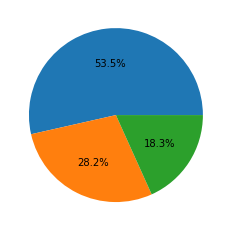

In [111]:
plt.pie(percent_defaults, autopct='%1.1f%%')

C:\Users\ayush\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Credit_Score', ylabel='count'>

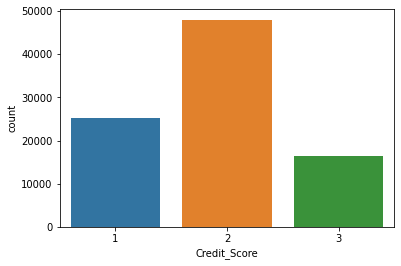

In [112]:
sns.countplot(df.Credit_Score)

<AxesSubplot:>

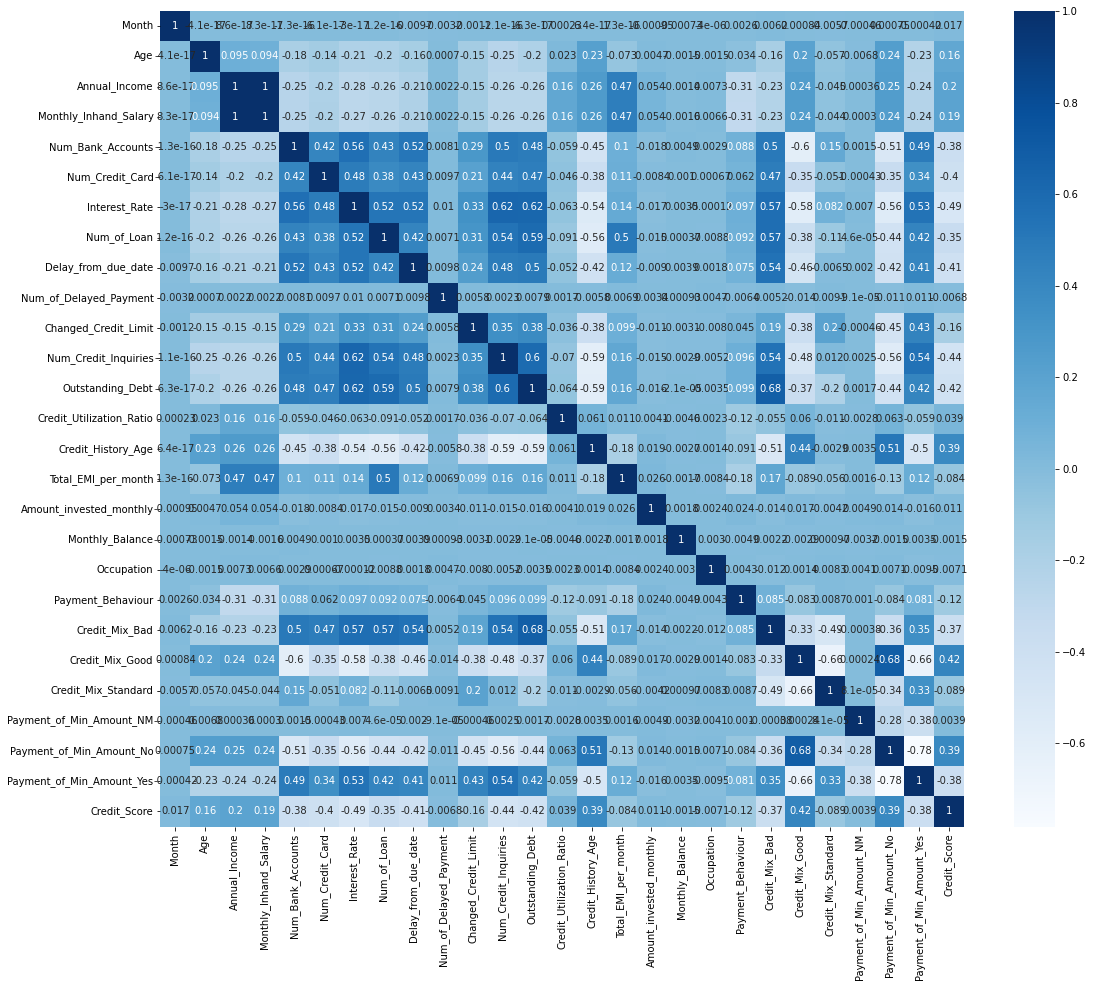

In [345]:
plt.subplots(figsize=(18,15))
sns.heatmap(df.corr(), annot=True, cmap='Blues')

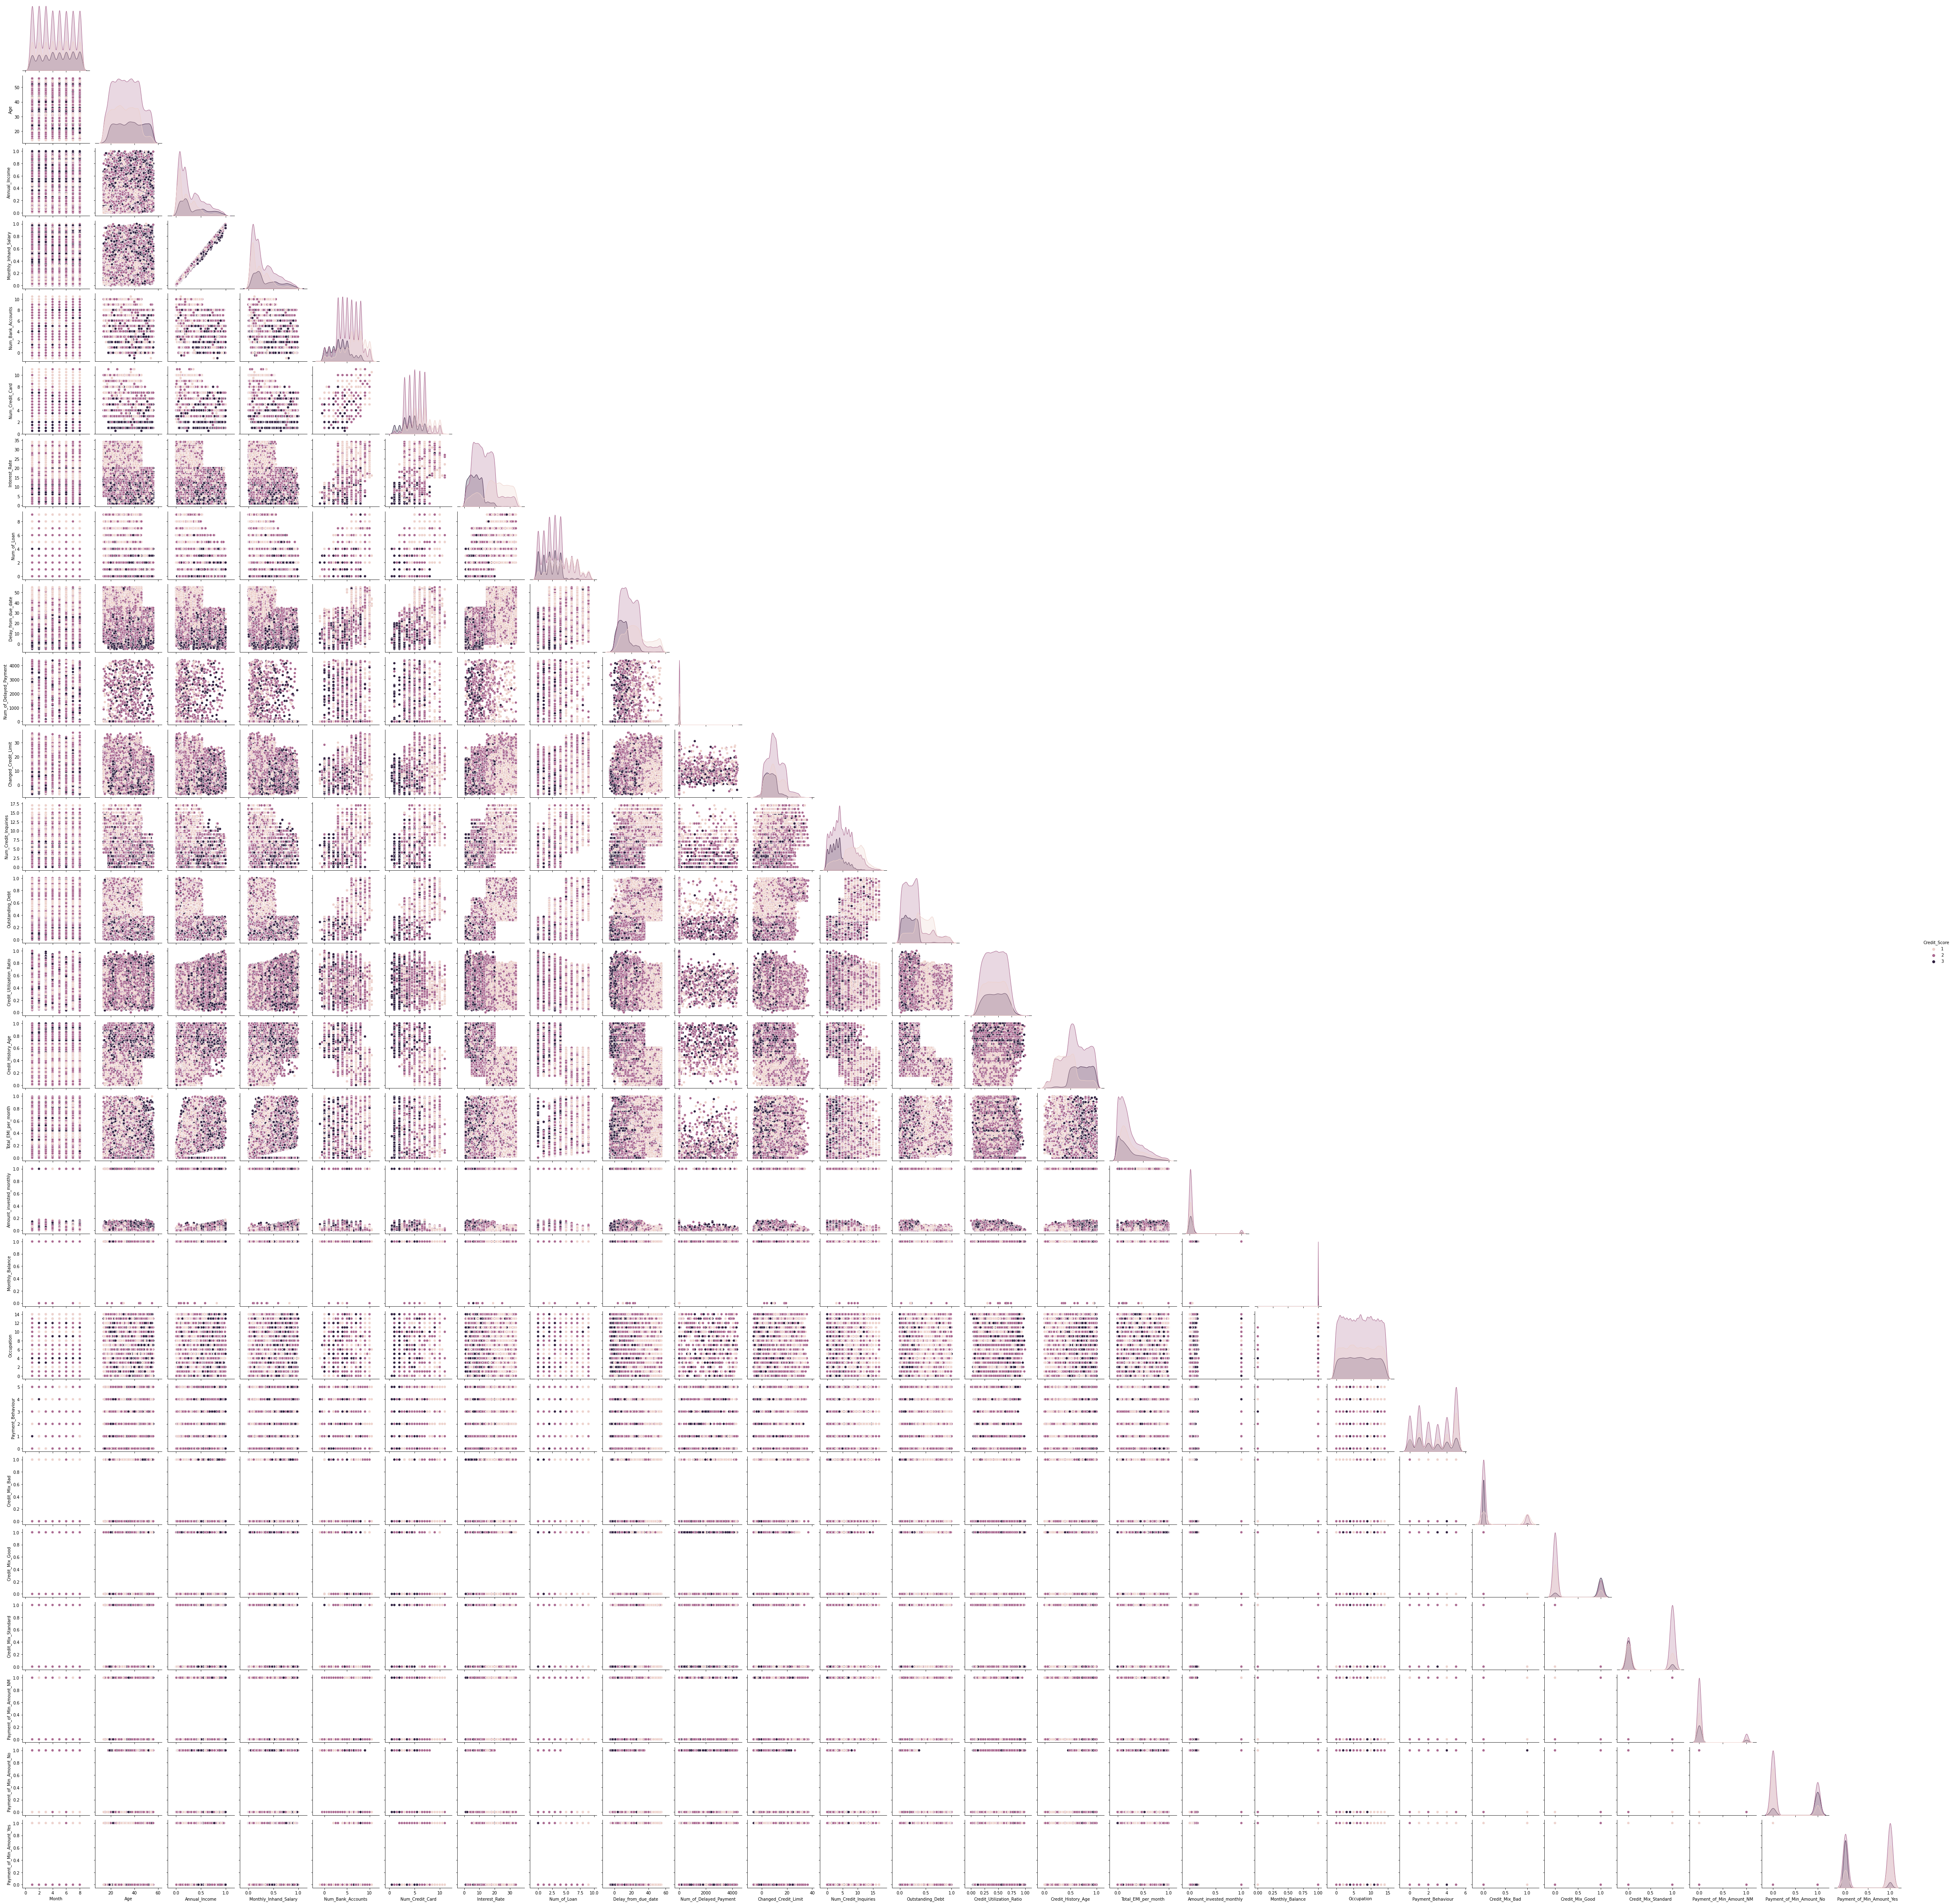

In [346]:
sns.pairplot(df, hue='Credit_Score', corner= True)

# Prediction Models

### Splitting the data

In [113]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(Final_X, y, test_size =0.2, random_state=42)

## Decision Tree Classifier

In [114]:
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier(max_depth=19)
model1.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=19)

In [115]:
from sklearn.metrics import accuracy_score
print('Training accuracy...', accuracy_score(y_train, model1.predict(X_train)))
print('Test accuracy', accuracy_score(y_test, model1.predict(X_test)))

Training accuracy... 0.8919126262344473
Test accuracy 0.7414081678196831


## Random Forest Classifier

In [116]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(random_state=1, n_estimators=500, max_depth=15, n_jobs=-1)

forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=500, n_jobs=-1,
                       random_state=1)

In [117]:
print("Training Score: " , accuracy_score(y_train,forest.predict(X_train)))
print("Test score: ", accuracy_score(y_test, forest.predict(X_test)))

Training Score:  0.8460497684539419
Test score:  0.7825820129435394


## Using Grid Search on Random Forest

In [118]:
from sklearn.model_selection import GridSearchCV
# Create the parameter grid based on the results of random search
param_grid = {
'bootstrap': [True, False],
'max_depth': [15, 20, 25, 30, 35],
'n_estimators': [ 100, 150, 200, 250, 300]}


rf = RandomForestClassifier(random_state = 1)

# Grid search cv
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid,
cv = 2, n_jobs = -1, verbose = 2)

In [119]:
grid_search.fit(X_train, y_train)

Fitting 2 folds for each of 50 candidates, totalling 100 fits


GridSearchCV(cv=2, estimator=RandomForestClassifier(random_state=1), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [15, 20, 25, 30, 35],
                         'n_estimators': [100, 150, 200, 250, 300]},
             verbose=2)

In [120]:
grid_search.best_params_

{'bootstrap': False, 'max_depth': 30, 'n_estimators': 200}

In [121]:
forest_new = RandomForestClassifier(random_state=1, n_estimators=200, max_depth=30, bootstrap =False)
forest_new.fit(X_train, y_train)

RandomForestClassifier(bootstrap=False, max_depth=30, n_estimators=200,
                       random_state=1)

In [122]:
print(" New Training Score: " , accuracy_score(y_train,forest_new.predict(X_train)))
print(" New Test score: ", accuracy_score(y_test, forest_new.predict(X_test)))

 New Training Score:  1.0
 New Test score:  0.836420441865655


## Using KNeighbours Classifier and Grid Search 

In [123]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_jobs=-1)
parameter = {
    'n_neighbors': range(1, 31, 2),
    'weights' : ['uniform', 'distance'],
    'p' : [1, 2] # manhattan or euclidean
}

model = GridSearchCV(classifier, 
                     param_grid=parameter,
                     cv=2,
                     n_jobs=-1,
                     scoring='accuracy', 
                     verbose=2)

model.fit(Final_X, y)

Fitting 2 folds for each of 60 candidates, totalling 120 fits


GridSearchCV(cv=2, estimator=KNeighborsClassifier(n_jobs=-1), n_jobs=-1,
             param_grid={'n_neighbors': range(1, 31, 2), 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [124]:
model.best_params_

{'n_neighbors': 29, 'p': 1, 'weights': 'uniform'}

In [125]:
model.best_score_

0.6701593465452598

In [126]:
classify = KNeighborsClassifier(n_neighbors=29, p=1, weights='uniform', n_jobs=-1)
classify.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=29, p=1)

In [127]:
print(" New Training Score: " , accuracy_score(y_train,classify.predict(X_train)))
print(" New Test score: ", accuracy_score(y_test, classify.predict(X_test)))

 New Training Score:  0.7481169447079172
 New Test score:  0.7302499442088819


In [128]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 71692 entries, 0x5955 to 0x7bc9
Series name: Credit_Score
Non-Null Count  Dtype
--------------  -----
71692 non-null  int64
dtypes: int64(1)
memory usage: 3.1+ MB


## Feature Importance Classification

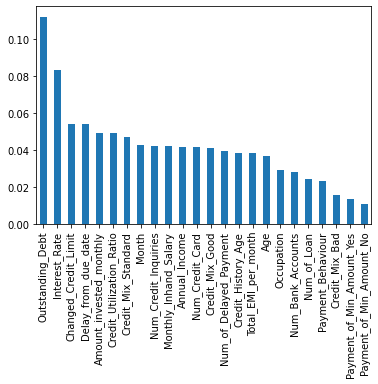

In [129]:
# Using important features Classification

# Create a random forest classifier
rf_clf = RandomForestClassifier(n_estimators=500, random_state=1, n_jobs=-1)

# n_estimators = The number of trees in the forest.
# n_jobs = -1 : Use all processors for training

# Train the classifier
rf_clf.fit(X_train, y_train)

#plot graph of feature importances for better visualization
feat_importances = pd.Series(rf_clf.feature_importances_, index=X_train.columns)
feat_importances.nlargest(24).plot(kind='bar')
plt.show()

In [130]:
X_imp=Final_X[['Outstanding_Debt', 'Interest_Rate', 'Changed_Credit_Limit', 'Delay_from_due_date', 'Amount_invested_monthly', 'Credit_Utilization_Ratio']]
y_imp=y

In [131]:
#Spliting Data for important features

X_imp_train, X_imp_test, y_imp_train, y_imp_test = train_test_split(X_imp, y_imp, test_size =0.2, random_state=42)

In [132]:
forest_imp = RandomForestClassifier(random_state=1, n_estimators=200, max_depth=30, bootstrap =False)
forest_imp.fit(X_imp_train, y_imp_train)

RandomForestClassifier(bootstrap=False, max_depth=30, n_estimators=200,
                       random_state=1)

In [133]:
print(" Imp features Training Score: " , accuracy_score(y_imp_train,forest_imp.predict(X_imp_train)))
print(" Imp Features Test score: ", accuracy_score(y_imp_test, forest_imp.predict(X_imp_test)))

 Imp features Training Score:  1.0
 Imp Features Test score:  0.7418544967641152


# Thus, we get a maximum accuracy of 83.64% with Random Forest Classifier using Grid Search Parameters 